In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.utils import resample
from collections import Counter

Original Class Distribution: Counter({np.int64(0): 894, np.int64(1): 106})


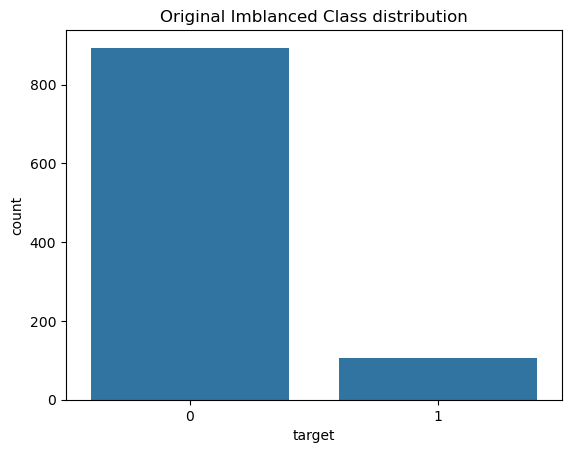

In [9]:
x, y = make_classification(n_classes=2, class_sep=2, weights =[0.9,0.1],n_informative=3, 
                           n_redundant=0, n_features=5, n_samples=1000, random_state=42)

df = pd.DataFrame(x,columns=[f"feature_{i}" for i in range(x.shape[1])])

df['target'] = y
print("Original Class Distribution:", Counter(y))
sns.countplot(x = df['target'])
plt.title("Original Imblanced Class distribution")
plt.show()



In [49]:
df_majority = df[df['target'] == 0]
df_minority = df[df['target'] == 1]


df_majority_oversampled = resample(df_minority, replace = True, n_samples=len(df_majority),random_state=42)
df_over = pd.concat([df_majority, df_minority_oversampled])
print("After oversampling :", Counter(df_over['target']))

After oversampling : Counter({0: 894, 1: 894})


In [51]:
df_majority_undersampled = resample(df_majority,replace = False, n_samples = len(df_minority),random_state=42)
df_under = pd.concat([df_majority_undersampled, df_minority])
print("After undersampling :", Counter(df_under['target']))

After undersampling : Counter({0: 106, 1: 106})


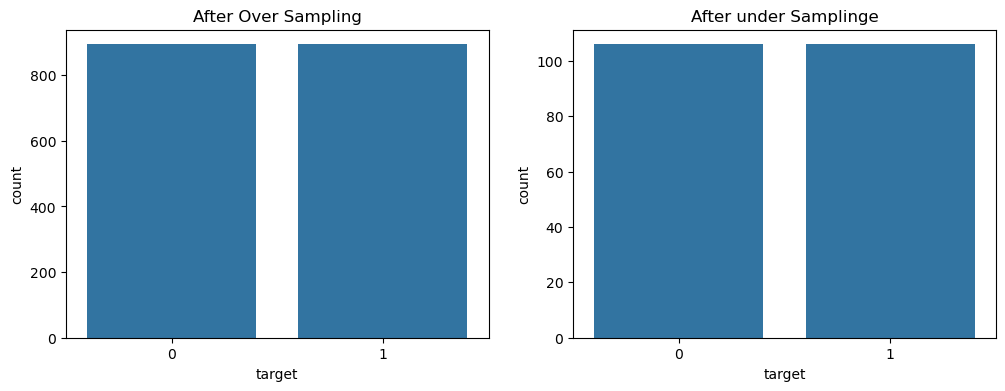

In [57]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.countplot(x=df_over['target'],ax = axes[0])
axes[0].set_title("After Over Sampling")
sns.countplot (x=df_under['target'],ax = axes[1])
axes[1].set_title("After under Samplinge")
plt.show()